In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

In [14]:
np.random.seed(42)
mean = [0, 0]
cov = [[3, 2], [2, 2]]
X = np.random.multivariate_normal(mean=mean, cov=cov, size=200)

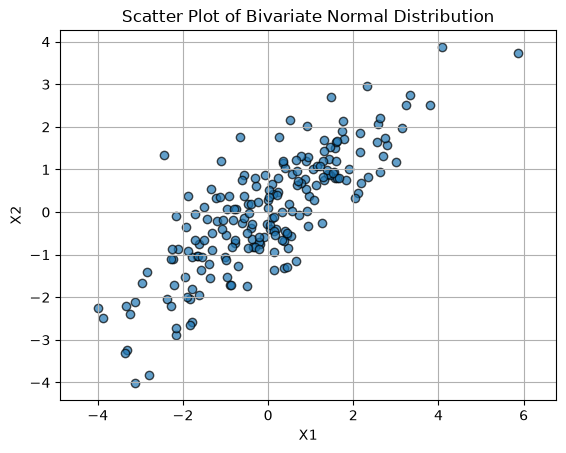

In [15]:
# enter your code here

# Scatter plot of the two features
plt.figure()
plt.scatter(X[:, 0], X[:, 1], edgecolor='k', alpha=0.7)
plt.title("Scatter Plot of Bivariate Normal Distribution")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis('equal')
plt.grid(True)
plt.show()

In [16]:
X

array([[-7.79842558e-01, -7.25035362e-01],
       [-1.71097070e+00, -5.64228380e-02],
       [ 4.89591649e-01,  1.85568480e-01],
       [-2.97122622e+00, -1.67515888e+00],
       [ 5.69236811e-01,  9.00239014e-01],
       [ 9.69916161e-01,  3.66038690e-01],
       [ 3.72329343e-01, -1.31659722e+00],
       [ 3.13291389e+00,  1.97374029e+00],
       [ 1.57697817e+00,  1.49525938e+00],
       [ 2.10410746e+00,  4.56393273e-01],
       [-2.37531795e+00, -2.04426174e+00],
       [ 4.66901868e-01, -8.32352558e-01],
       [ 8.71231068e-01,  7.73420205e-01],
       [ 1.78452439e+00,  1.70892989e+00],
       [ 1.12999928e+00,  6.37231499e-01],
       [ 2.58134249e-01,  1.75760187e+00],
       [ 4.53736035e-01, -5.34292484e-01],
       [-8.87208561e-01, -1.71831447e+00],
       [ 4.46952492e-01, -1.29730430e+00],
       [ 2.15569151e+00,  1.84849172e+00],
       [-1.31299097e+00, -8.81189775e-01],
       [ 3.17385058e-01, -5.14359599e-03],
       [ 2.78232697e+00,  1.56765052e+00],
       [ 3.

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [18]:
components = pca.components_
components

array([[ 0.78215821,  0.62307987],
       [-0.62307987,  0.78215821]])

In [19]:
pca.explained_variance_ratio_

array([0.9111946, 0.0888054])

In [22]:
projection_pc1 = np.dot(X, components[0])
projection_pc2 = np.dot(X, components[1])

In [23]:
x_pc1 = projection_pc1 * components[0][0]
y_pc1 = projection_pc1 * components[0][1]
x_pc2 = projection_pc2 * components[1][0]
y_pc2 = projection_pc2 * components[1][1]

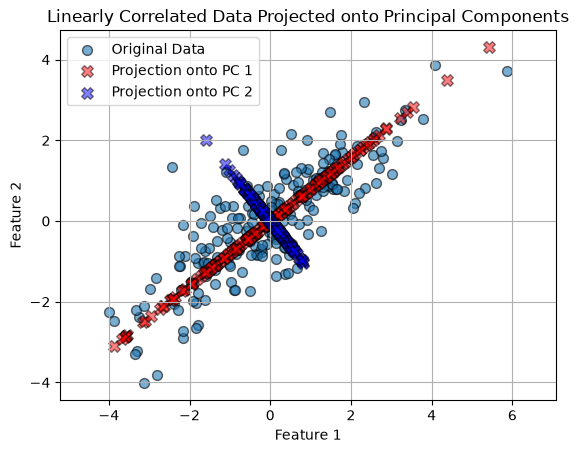

In [24]:
# Plot original data
plt.figure()
plt.scatter(X[:, 0], X[:, 1], label='Original Data', ec='k', s=50, alpha=0.6)

# Plot the projections along PC1 and PC2
plt.scatter(x_pc1, y_pc1, c='r', ec='k', marker='X', s=70, alpha=0.5, label='Projection onto PC 1')
plt.scatter(x_pc2, y_pc2, c='b', ec='k', marker='X', s=70, alpha=0.5, label='Projection onto PC 2')
plt.title('Linearly Correlated Data Projected onto Principal Components', )
plt.xlabel('Feature 1',)
plt.ylabel('Feature 2',)
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [25]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
iris["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [28]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

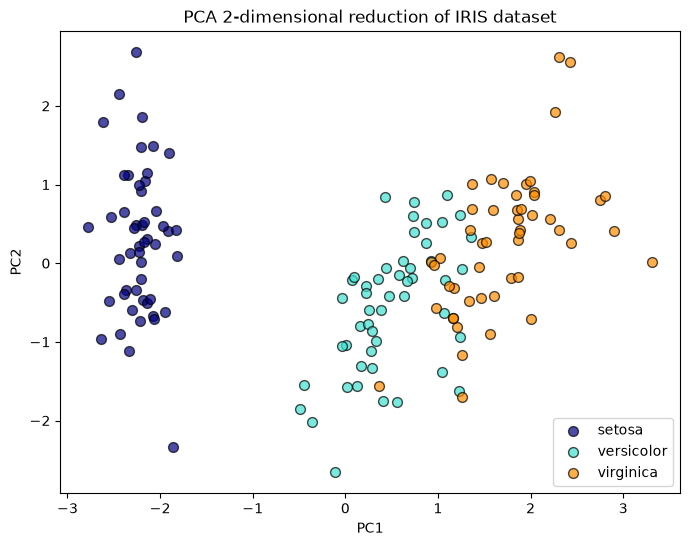

In [29]:
# Plot the PCA-transformed data in 2D
plt.figure(figsize=(8,6))

colors = ['navy', 'turquoise', 'darkorange']
lw = 1

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, s=50, ec='k',alpha=0.7, lw=lw,
                label=target_name)

plt.title('PCA 2-dimensional reduction of IRIS dataset',)
plt.xlabel("PC1",)
plt.ylabel("PC2",)
plt.legend(loc='best', shadow=False, scatterpoints=1,)
# plt.grid(True)
plt.show()

In [30]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

In [ ]:
100*pca.explained_variance_ratio_.sum()

np.float64(95.81320720000164)

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

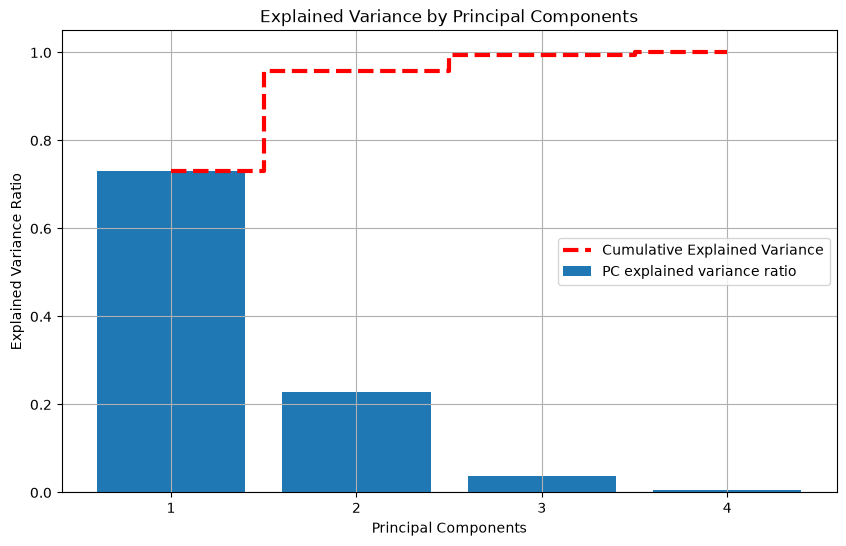

In [33]:
# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Plot explained variance ratio for each component
plt.figure(figsize=(10,6))
plt.bar(x=range(1, len(explained_variance_ratio)+1), height=explained_variance_ratio, alpha=1, align='center', label='PC explained variance ratio' )
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Explained Variance by Principal Components')

# Plot cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)
plt.step(range(1, 5), cumulative_variance, where='mid', linestyle='--', lw=3,color='red', label='Cumulative Explained Variance')
# Only display integer ticks on the x-axis
plt.xticks(range(1, 5))
plt.legend()
plt.grid(True)
plt.show()